In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## Обработка пропусков

In [3]:
print(len(df.drop_duplicates()))
df = df.drop_duplicates()
df = df.reset_index(drop=True)

784


In [4]:
df = df.drop('deck', axis=1)
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,Queenstown,no,False
780,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
781,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,Southampton,no,False
782,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [5]:
df[df['embarked'].isna()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
60,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,NaN,yes,True
734,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,NaN,yes,True


In [6]:
df = df.drop([60, 734], axis=0)
df = df.reset_index(drop=True)
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,Queenstown,no,False
778,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
779,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,Southampton,no,False
780,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [7]:
df.groupby(['sex','class'])['age'].median()

sex     class 
female  First     35.0
        Second    28.0
        Third     22.0
male    First     40.0
        Second    30.5
        Third     25.0
Name: age, dtype: float64

In [8]:
df.groupby(['sex','class'])['age'].mean()

sex     class 
female  First     34.365854
        Second    28.429577
        Third     21.957921
male    First     41.281386
        Second    31.083295
        Third     26.576910
Name: age, dtype: float64

In [9]:
df['age'] = df['age'].fillna(df.groupby(['class', 'sex'])['age'].transform('median'))
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,Queenstown,no,False
778,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
779,0,3,female,22.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False
780,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     782 non-null    int64   
 1   pclass       782 non-null    int64   
 2   sex          782 non-null    str     
 3   age          782 non-null    float64 
 4   sibsp        782 non-null    int64   
 5   parch        782 non-null    int64   
 6   fare         782 non-null    float64 
 7   embarked     782 non-null    str     
 8   class        782 non-null    category
 9   who          782 non-null    str     
 10  adult_male   782 non-null    bool    
 11  embark_town  782 non-null    str     
 12  alive        782 non-null    str     
 13  alone        782 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(5)
memory usage: 69.8 KB


## Подготовка признаков и обучение модели логистической регрессии


In [11]:
df_prep = df.drop(['class', 'embark_town', 'alive', 'who'], axis=1)
df_prep

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,True,False
1,1,1,female,38.0,1,0,71.2833,C,False,False
2,1,3,female,26.0,0,0,7.9250,S,False,True
3,1,1,female,35.0,1,0,53.1000,S,False,False
4,0,3,male,35.0,0,0,8.0500,S,True,True
...,...,...,...,...,...,...,...,...,...,...
777,0,3,female,39.0,0,5,29.1250,Q,False,False
778,1,1,female,19.0,0,0,30.0000,S,False,True
779,0,3,female,22.0,1,2,23.4500,S,False,False
780,1,1,male,26.0,0,0,30.0000,C,True,True


In [12]:
df_prep = pd.get_dummies(df_prep, columns=['sex', 'embarked', 'adult_male', 'alone'], drop_first=True, dtype=np.int64)
df_prep

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S,adult_male_True,alone_True
0,0,3,22.0,1,0,7.2500,1,0,1,1,0
1,1,1,38.0,1,0,71.2833,0,0,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1,0,1
3,1,1,35.0,1,0,53.1000,0,0,1,0,0
4,0,3,35.0,0,0,8.0500,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
777,0,3,39.0,0,5,29.1250,0,1,0,0,0
778,1,1,19.0,0,0,30.0000,0,0,1,0,1
779,0,3,22.0,1,2,23.4500,0,0,1,0,0
780,1,1,26.0,0,0,30.0000,1,0,0,1,1


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_prep.drop('survived', axis=1)
y = df_prep['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegressionCV

model = LogisticRegressionCV(
    Cs=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

model.fit(scaled_X_train, y_train)

pred = model.predict(scaled_X_test)

D:\my-first-notebook\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2071: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
D:\my-first-notebook\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2129: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


## Подсчет метрик логичтической регрессии

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.76      0.85      0.80        88
           1       0.78      0.65      0.71        69

    accuracy                           0.76       157
   macro avg       0.77      0.75      0.76       157
weighted avg       0.77      0.76      0.76       157



In [16]:
confusion_matrix(y_test, pred)

array([[75, 13],
       [24, 45]])

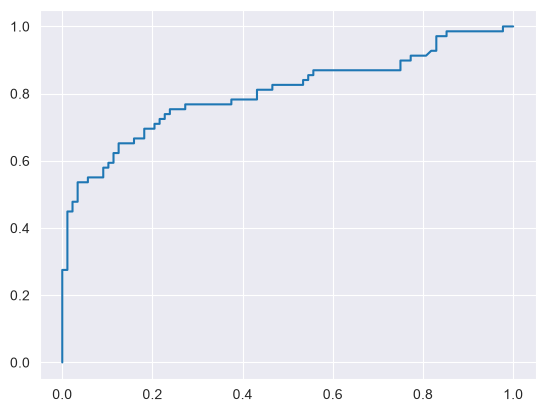

In [17]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

pred_prob = model.predict_proba(scaled_X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, pred_prob)

plt.plot(fpr, tpr)

## Модель, которая предсказывает самый частый класс

In [18]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_model.fit(scaled_X_train, y_train)

dummy_pred = dummy_model.predict(X_test)
dummy_pred_proba = dummy_model.predict_proba(X_test)[:, 1]

In [19]:
print(classification_report(y_test, dummy_pred))

D:\my-first-notebook\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\my-first-notebook\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\my-first-notebook\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       0.56      1.00      0.72        88
           1       0.00      0.00      0.00        69

    accuracy                           0.56       157
   macro avg       0.28      0.50      0.36       157
weighted avg       0.31      0.56      0.40       157



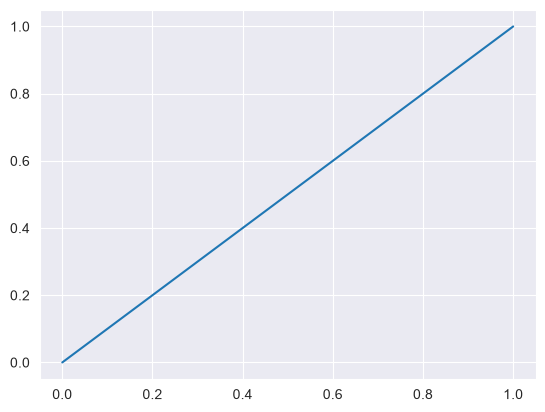

In [20]:
d_fpr, d_tpr, d_thresholds = roc_curve(y_test, dummy_pred_proba)

plt.plot(d_fpr, d_tpr)